# Demo: Pig and Value Iteration

This notebook demonstrates the four-file package structure:

```text
optimal_pig/
├── piglet.py
├── pig.py
├── value_iteration.py
└── analysis_helpers.py
```

The goal is to verify that:

1. `pig.py` can run the Pig game.
2. `value_iteration.py` solves the optimal win-probability equations.
3. `analysis_helpers.py` extracts validation results and article-style visualization data.
4. The numerical results align with the paper *Optimal Play of the Dice Game Pig*.

**We structure the notebook as follows:**

1. Import modules  
2. Run pig  
3. Verify state-space definitions  

4. Value iteration on pig with target score $20$

* 4.1. Restricted state space $k$: States where we have already won are removed from consideration  
* 4.2. Unrestricted state space $k$: $0 \le k < \text{target score}$  
* 4.3. Comparison  
* 4.4. Performance of optimal pig policy against optimal and baseline pig policy  
* 4.5. Transform data for visualisations  
* 4.6. Visualisations  

5. Value iteration on pig with target score $100$

* 5.1. Visualisations on unrestricted state space $k$: $0 \le k < \text{target score}$
* 5.2. Visualisations on restricted state space $k$
* 5.3. Performance of optimal pig policy from the unrestricted state space against the hold-at-20 pig policy  

6. Checklist

Please note that the full visualisations used to generate the report can be found in the experiments folder.

## 1. Import modules

The cell below tries both `Code/` and `code/` as module locations. This is useful if your local folder uses a capital `Code`, as in many Windows projects.

In [1]:
# Import modules
from pathlib import Path
import sys
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import optimal_pig as op

print("Imported modules successfully.")

Imported modules successfully.


## 2. Run the games directly

This section verifies that the game simulators work independently of value iteration.

These simulations are random because the games involve coin flips or dice rolls. The random seed controls only the simulated game path, not the value-iteration solution.

Both players use a naive hold at $5$ policy (they will continue rolling until $k = 5$, at which point they will hold).

In [2]:
# Pig demo: target score 20 for a short game.
# Both players use a simple threshold policy.
pig_policy = op.make_hold_at_policy(threshold=5, target_score=20)

pig_final = op.play_pig(
    policy0=pig_policy,
    policy1=pig_policy,
    target_score=20,
    seed=2,
    first_player=0,
)

print("Pig final state:")
print(pig_final)

Pig final state:
PigState(scores=(24, 16), turn_total=0, current_player=0, winner=0)


## 3. Verify state-space definitions

The article uses the state

$(i,j,k),$


where:

- `i` is the current player's banked score,
- `j` is the opponent's banked score,
- `k` is the current turn total.

For target score \(G\), valid non-terminal states satisfy:

$
0 \le i < G, \qquad 0 \le j < G, \qquad 0 \le k < G-i, \text{  or  } 0 \le k < G$.

The former is referred to as the restricted case, and can be selected by setting `restricted_k = True`. This is faster and follows the method described in the paper. However, to obtain the diagrams in the paper, we use `restricted_k = False` when target score $=100$ to obtain the upper curve.

For full Pig with \(G=100\), using the restricted $k$ setting, the number of valid states is:

$100 \times (100 + 99 + \cdots + 1) = 505000.$


In [3]:
pig_spec_100 = op.make_spec(target_score=100)

print("Full Pig target=100 state count:", op.count_states(pig_spec_100))

assert op.count_states(pig_spec_100) == 505000
print("State-space check passed.")

Full Pig target=100 state count: 505000
State-space check passed.


## 4. Small Pig: compare full value iteration and partitioned value iteration

The full Pig game has 505,000 states. For a fast correctness test, we use a smaller Pig target score.

This section checks that:

1. The general full Jacobi value iteration works.
2. The article-aligned partitioned value iteration works.
3. Both produce the same value table on a small Pig problem.

The partitioned algorithm is the one intended for full Pig. It solves states by descending score sum \(i+j\), matching the acceleration idea described in the paper.

We also report a summary:

- target score,
- number of valid states,
- start-state win probability \(P_{0,0,0}\),
- number of states where continuing is optimal,
- number of states where holding is optimal.

For `target_score=20`, the start probability is for the small demo game, not the full paper game.

### 4.1 $0 \le k < G-i$

In [4]:
%%time

restricted_k = True

small_target = 20
small_pig_spec = op.make_spec(target_score=small_target)

small_full = op.value_iteration(
    small_pig_spec,
    tol=1e-11,
    max_iterations=100_000,
    init_value=0.0,
    restricted_k = restricted_k
)

small_part = op.partitioned_value_iteration(
    small_pig_spec,
    tol=1e-11,
    max_local_iterations=100_000,
    init_value=0.0,
    progress=False,
    restricted_k = restricted_k,
)

V_full = small_full["V"]
V_part = small_part["V"]
policy_small = small_part["policy"]

valid_mask = op.valid_state_mask(small_pig_spec, restricted_k = restricted_k)
max_abs_diff = np.nanmax(np.abs(V_full[valid_mask] - V_part[valid_mask]))

print("Small Pig target:", small_target)
print("Full VI converged:", small_full["converged"], "iterations:", small_full["iterations"])
print("Partitioned VI converged:", small_part["converged"])
print("Max absolute difference between methods:", max_abs_diff)

assert max_abs_diff < 1e-8
print("Small Pig solver consistency check passed.")

Small Pig target: 20
Full VI converged: True iterations: 122
Partitioned VI converged: True
Max absolute difference between methods: 1.0141476547431694e-10
Small Pig solver consistency check passed.
CPU times: user 5.29 s, sys: 7.59 ms, total: 5.29 s
Wall time: 5.33 s


In [5]:
small_summary = op.summarize_solution(small_pig_spec, V_part, policy_small, restricted_k = restricted_k)
small_summary

{'target_score': 20,
 'n_valid_states': 4200,
 'start_win_probability': 0.6155585498033931,
 'n_continue_states': 4200,
 'n_hold_states': 0}

### 4.2 $0\le k < G$

In [6]:
%%time

restricted_k = False

small_target = 20
small_pig_spec = op.make_spec(target_score=small_target)

small_full = op.value_iteration(
    small_pig_spec,
    tol=1e-11,
    max_iterations=100_000,
    init_value=0.0,
    restricted_k = restricted_k
)

small_part = op.partitioned_value_iteration(
    small_pig_spec,
    tol=1e-11,
    max_local_iterations=100_000,
    init_value=0.0,
    progress=False,
    restricted_k = restricted_k,
)

V_full = small_full["V"]
V_part = small_part["V"]
policy_small = small_part["policy"]

valid_mask = op.valid_state_mask(small_pig_spec, restricted_k = True) # only want to consider the region where we haven't already won
max_abs_diff = np.nanmax(np.abs(V_full[valid_mask] - V_part[valid_mask]))

print("Small Pig target:", small_target)
print("Full VI converged:", small_full["converged"], "iterations:", small_full["iterations"])
print("Partitioned VI converged:", small_part["converged"])
print("Max absolute difference between methods:", max_abs_diff)

assert max_abs_diff < 1e-8
print("Small Pig solver consistency check passed.")

Small Pig target: 20
Full VI converged: True iterations: 122
Partitioned VI converged: True
Max absolute difference between methods: 1.0141476547431694e-10
Small Pig solver consistency check passed.
CPU times: user 8 s, sys: 28 ms, total: 8.03 s
Wall time: 8.06 s


In [7]:
small_summary = op.summarize_solution(small_pig_spec, V_part, policy_small, restricted_k = restricted_k)
small_summary

{'target_score': 20,
 'n_valid_states': 8000,
 'start_win_probability': 0.6155585498033931,
 'n_continue_states': 4200,
 'n_hold_states': 3800}

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


### 4.3 Comparison

The number of valid states is substantially larger when $0\le k < G$ compared to $0\le k < G-i$. The 'additional' valid states in the first case all have a 'hold' policy as they have already won. On our system, it takes 7.38 seconds to run the former, and 5.22 seconds to run the latter.

Crucially, the winning probability is the same. 

## 4.4. Use the solved small Pig policy in the Pig simulator

This converts the solved value table into a real game-playing policy.

Important distinction:

- Value iteration is deterministic.
- Running a game is random because dice rolls are random.

We play our optimal policy against itself and against a baseline policy. We define this baseline policy as we roll until our current round score is $5$ or we have rolled a $1$ and the turn ends. (This is also known as a hold at $5$ policy.) 

In [8]:
print("Is k restricted?", restricted_k)

small_optimal_policy = op.optimal_policy_function(small_pig_spec, V_part, restricted_k = restricted_k)
small_baseline_policy = op.make_hold_at_policy(threshold=5, target_score=small_target)

opt_vs_opt = op.play_pig(
    policy0=small_optimal_policy,
    policy1=small_optimal_policy,
    target_score=small_target,
    seed=10,
    first_player=0,
)

opt_vs_baseline = op.play_pig(
    policy0=small_optimal_policy,
    policy1=small_baseline_policy,
    target_score=small_target,
    seed=11,
    first_player=0,
)

print("Small Pig, optimal vs optimal:")
print(opt_vs_opt)
print("Small Pig, optimal vs baseline:")
print(opt_vs_baseline)

Is k restricted? False
Small Pig, optimal vs optimal:
PigState(scores=(21, 0), turn_total=0, current_player=0, winner=0)
Small Pig, optimal vs baseline:
PigState(scores=(22, 0), turn_total=0, current_player=0, winner=0)


## 4.5. Extract visualization data for the small Pig game

The paper visualizes several objects:

- roll/hold boundary,
- fixed-opponent-score cross-section,
- reachable states,
- reachable states where rolling is optimal,
- win-probability contours.

Here we generate the same types of data on the small Pig game. The shapes are not expected to match the full paper figures exactly because the target score is 20 rather than 100.

In [9]:
def choose_valid_opponent_score(policy, preferred=None):
    # Choose an opponent score whose cross-section has at least one finite boundary.
    B = op.hold_boundary(policy)
    G = B.shape[0]

    if preferred is not None and 0 <= preferred < G and np.isfinite(B[:, preferred]).any():
        return preferred

    for j in range(G):
        if np.isfinite(B[:, j]).any():
            return j

    return None

fig3_data = op.figure3_boundary_data(policy_small)

j_demo = choose_valid_opponent_score(policy_small, preferred=min(30, small_target - 1))
if j_demo is None:
    print("No valid finite cross-section boundary was found for the small Pig policy.")
    fig4_data = None
else:
    fig4_data = op.figure4_cross_section_data(policy_small, opponent_score=j_demo)
    print("Chosen opponent score for cross-section:", j_demo)

fig5_data = op.figure5_reachable_data(small_pig_spec, policy_small, opponent_mode="any", restricted_k = restricted_k)
fig6_data = op.figure6_reachable_continue_data(small_pig_spec, policy_small, opponent_mode="any", restricted_k = restricted_k)
fig7_data = op.figure7_probability_contour_data(
    small_pig_spec,
    V_part,
    levels=(0.03, 0.09, 0.27, 0.81),
    restricted_k = restricted_k,
)

print("Boundary points:", fig3_data["points"].shape)
print("Reachable points:", fig5_data["points"].shape)

Chosen opponent score for cross-section: 19
Boundary points: (380, 3)
Reachable points: (361, 3)


## 4.6. Plot small Pig article-style figures

These plots are mainly functional checks. The full article visualizations should be generated with `target_score=100`.

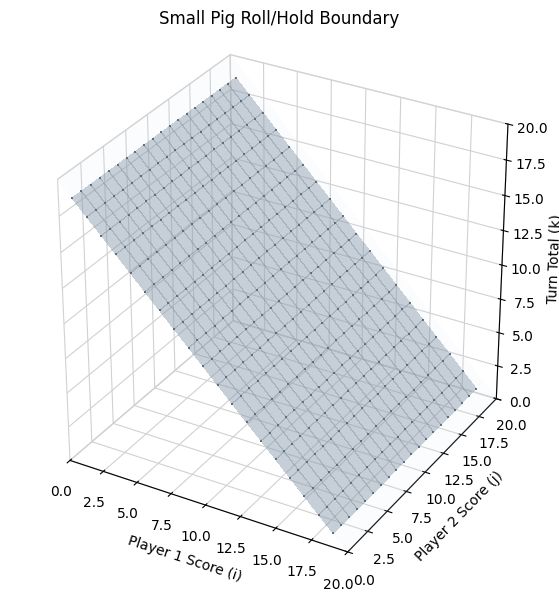

In [10]:
op.plot_figure3_policy_boundary(fig3_data, title="Small Pig Roll/Hold Boundary")
plt.show()

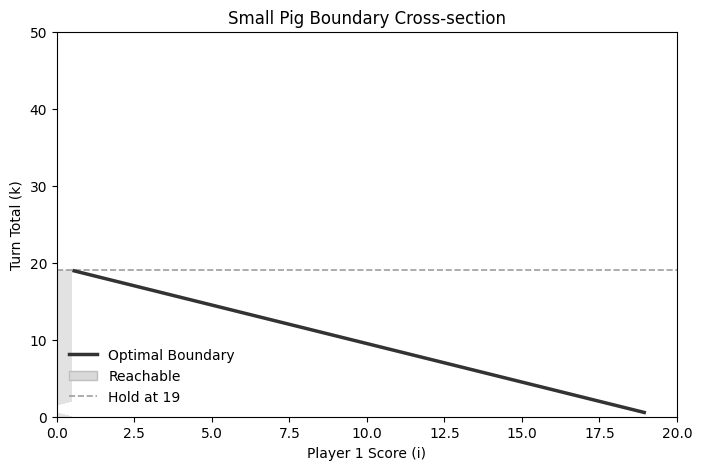

In [11]:
if fig4_data is not None:
    op.plot_figure4_cross_section(
        fig4_data,
        hold_at_threshold=min(20, small_target - 1),
        title="Small Pig Boundary Cross-section",
    )
    plt.show()
else:
    print("Skipping Figure 4-style plot because there is no finite boundary cross-section.")

## 5. Solve the full Pig game from the paper

The full paper setting is:

```text
Pig target score = 100
```

The paper reports that if both players play optimally, the starting player wins approximately:

$P_{0,0,0} \approx 0.5306.$

This cell is disabled by default because the full computation can take longer. Set `RUN_FULL_PIG = True` to run it. 

We use the unrestricted $0 \le k < G$ to obtain the graphs in the paper. This takes approximately $16$ minutes $50$ seconds on our system. 

In [12]:
%%time

RUN_FULL_PIG = True 

restricted_k = False

if RUN_FULL_PIG:
    full_pig_spec = op.make_spec(target_score=100)

    full_result = op.partitioned_value_iteration(
        full_pig_spec,
        tol=1e-12,
        max_local_iterations=100_000,
        init_value=0.0,
        progress=True,
        restricted_k = restricted_k
    )

    full_V = full_result["V"]
    full_policy = full_result["policy"]

    print("Full Pig converged:", full_result["converged"])
    print("P[0,0,0] =", full_V[0, 0, 0])

    err = op.check_pig_start_probability(full_V, expected=0.5306, atol=1e-3)
    print("Start-probability check passed. Absolute error:", err)

    full_summary = op.summarize_solution(full_pig_spec, full_V, full_policy, restricted_k = restricted_k)
    print("Full Pig summary:")
    print(full_summary)
else:
    print("Full Pig solve skipped. Set RUN_FULL_PIG = True to run it.")

Solving score_sum=198
Solving score_sum=197
Solving score_sum=196
Solving score_sum=195
Solving score_sum=194
Solving score_sum=193
Solving score_sum=192
Solving score_sum=191
Solving score_sum=190
Solving score_sum=189
Solving score_sum=188
Solving score_sum=187
Solving score_sum=186
Solving score_sum=185
Solving score_sum=184
Solving score_sum=183
Solving score_sum=182
Solving score_sum=181
Solving score_sum=180
Solving score_sum=179
Solving score_sum=178
Solving score_sum=177
Solving score_sum=176
Solving score_sum=175
Solving score_sum=174
Solving score_sum=173
Solving score_sum=172
Solving score_sum=171
Solving score_sum=170
Solving score_sum=169
Solving score_sum=168
Solving score_sum=167
Solving score_sum=166
Solving score_sum=165
Solving score_sum=164
Solving score_sum=163
Solving score_sum=162
Solving score_sum=161
Solving score_sum=160
Solving score_sum=159
Solving score_sum=158
Solving score_sum=157
Solving score_sum=156
Solving score_sum=155
Solving score_sum=154
Solving sc

In [13]:
# Save output
import pickle

save = False

if save:
    full_solution = {
        "target_score": 100,
        "restricted_k": restricted_k,
        "V": full_V,
        "policy": full_policy,
    }
    
    with open("pig_full_policy.pkl", "wb") as f:
        pickle.dump(full_policy, f)
    
    with open("pig_full_solution.pkl", "wb") as f:
        pickle.dump(full_solution, f)
    
    print("Saved pig_full_policy.pkl")
    print("Saved pig_full_solution.pkl")

## 5.1. Generate full paper-style visualization data

Run this only after the full Pig solve has completed. The data objects correspond to the paper's main visualizations:

- Figure 3: roll/hold boundary,
- Figure 4: cross-section at opponent score 30,
- Figure 5: reachable states,
- Figure 6: reachable states where rolling is optimal,
- Figure 7: win-probability contours at 3%, 9%, 27%, and 81%.

Note that Figure 7 requires the full value table full_V. If only pig_full_policy.pkl is available, Figures 3-6 still work and Figure 7 is skipped.

In [14]:
# Change data format for figures
if RUN_FULL_PIG:
    full_fig3_data = op.figure3_boundary_data(full_policy)
    
    full_fig5_data = op.figure5_reachable_data(
        full_pig_spec,
        full_policy,
        opponent_mode="any",
        restricted_k=restricted_k,
    )
    
    full_fig4_data = op.figure4_cross_section_data(
        full_policy,
        opponent_score=30,
        spec=full_pig_spec,
        reachable=full_fig5_data["reachable"],
        restricted_k=restricted_k,
    )
    
    full_fig6_data = op.figure6_reachable_continue_data(
        full_pig_spec,
        full_policy,
        opponent_mode="any",
        restricted_k=restricted_k,
    )
    
    if full_V is not None:
        full_fig7_data = op.figure7_probability_contour_data(
            full_pig_spec,
            full_V,
            levels=(0.03, 0.09, 0.27, 0.81),
            restricted_k=restricted_k,
        )
    else:
        full_fig7_data = None
    
    print("Full Figure 3 boundary points:", full_fig3_data["points"].shape)
    print("Full Figure 4 transition points:", full_fig4_data["transition_points"].shape)
    print("Full Figure 5 reachable points:", full_fig5_data["points"].shape)
    print("Full Figure 6 reachable-roll points:", full_fig6_data["points"].shape)
    if full_fig7_data is None:
        print("Full Figure 7 data skipped because full_V is not available.")
else:
    print("Full figure-data generation skipped because RUN_FULL_PIG is False.")

Full Figure 3 boundary points: (9984, 3)
Full Figure 4 transition points: (134, 5)
Full Figure 5 reachable points: (179577, 3)
Full Figure 6 reachable-roll points: (160879, 3)


#### 5.1.1. Figure 3

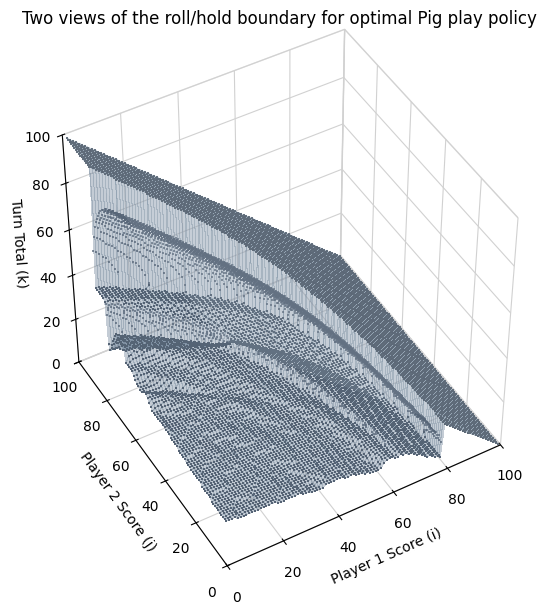

In [15]:
ax = op.plot_figure3_policy_boundary(full_fig3_data, 
                                     title="Two views of the roll/hold boundary for optimal Pig play policy")
ax.view_init(elev=45, azim=240)
plt.show()

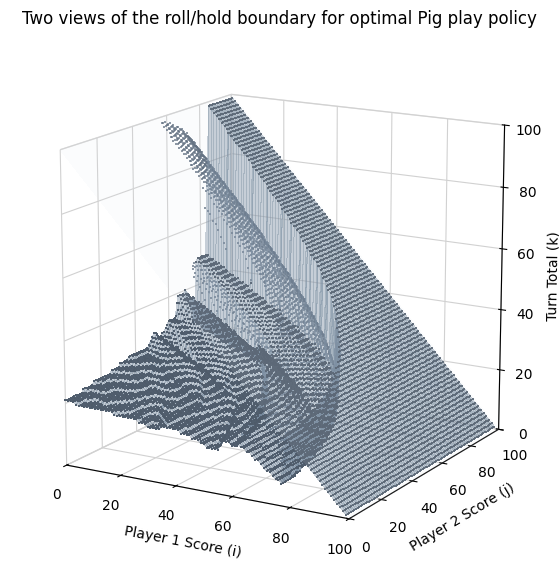

In [16]:
ax = op.plot_figure3_policy_boundary(full_fig3_data, 
                                     title="Two views of the roll/hold boundary for optimal Pig play policy")
ax.view_init(elev=15, azim=-60)
plt.show()

#### 5.1.2. Figure 4

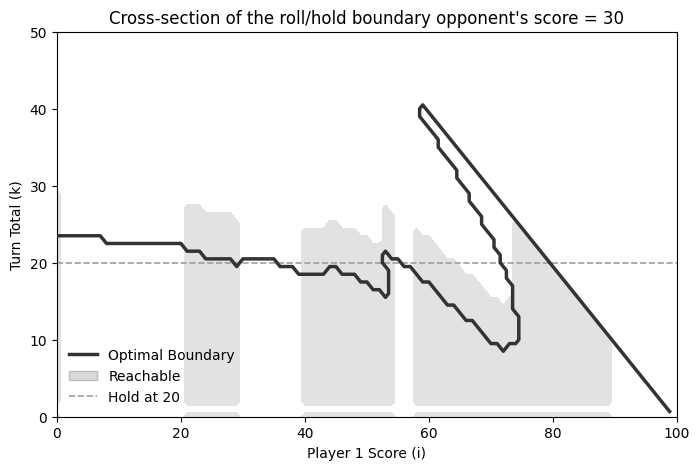

In [17]:
op.plot_figure4_cross_section(
    full_fig4_data,
    hold_at_threshold=20,
    title="Cross-section of the roll/hold boundary opponent's score = 30"
)
plt.ylim(0, 50)
plt.xlim(0, 100)
plt.show()

#### 5.1.3. Figure 5

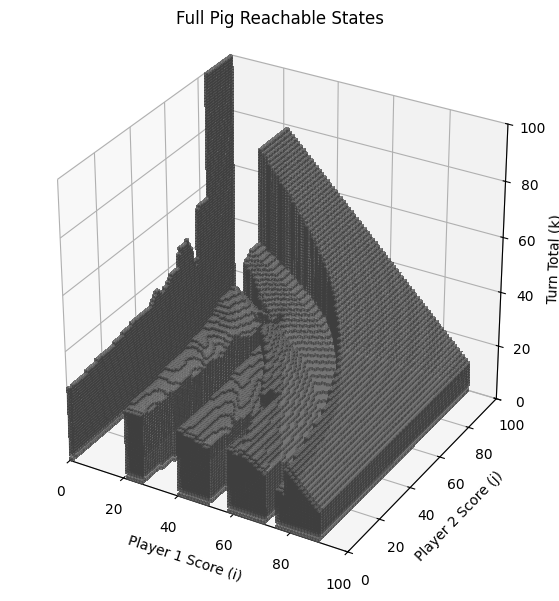

In [18]:
op.plot_figure5_reachable_states(
    full_fig5_data,
    max_points=60000,
    title="Full Pig Reachable States"
)
plt.show()

#### 5.1.4. Figure 6

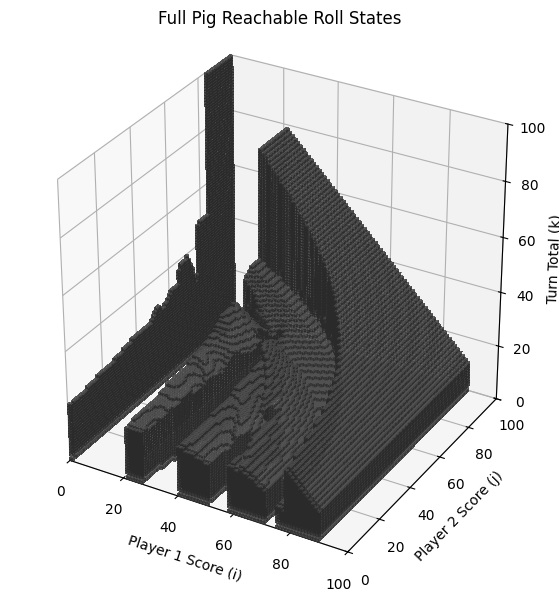

In [19]:
op.plot_figure6_reachable_continue_states(
    full_fig6_data,
    max_points=60000,
    title="Full Pig Reachable Roll States"
)
plt.show()

#### 5.1.5. Figure 7

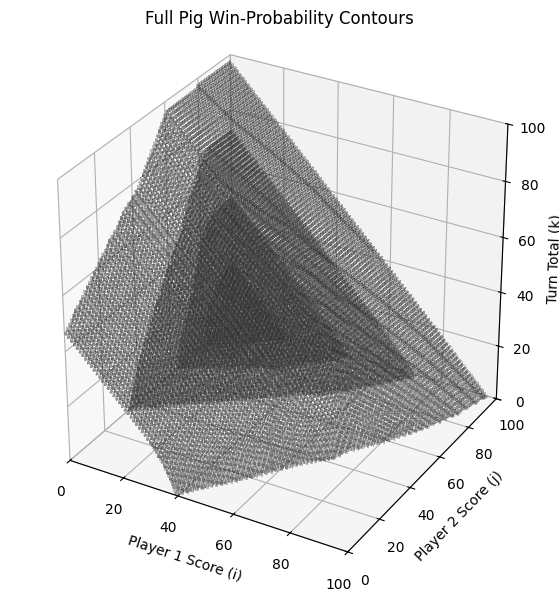

In [20]:
op.plot_figure7_probability_contours(
    full_fig7_data,
    title="Full Pig Win-Probability Contours"
)
plt.show()

## 5.2. Restricted $k$, $0 \le k < G - i$

As with the smaller target score version of pig, we can consider every combination of states (including states we would automatically win in) or a subset of states. The former naturally increases the computational time, with setting $0 \le k < G$ taking $16$ minutes and $50$ seconds while $0 \le k < G-i$ taking $10$ minutes and $50$ seconds. However, this was necessary to create the plots in Neller and Presser's paper. 

To demonstrate why this is important, we re-run the previous section with `restricted_k = True` and recreate Figures $3$ and $4$.

In [21]:
%%time

RUN_FULL_PIG = True 

restricted_k = True

if RUN_FULL_PIG:
    full_pig_spec = op.make_spec(target_score=100)

    full_result = op.partitioned_value_iteration(
        full_pig_spec,
        tol=1e-12,
        max_local_iterations=100_000,
        init_value=0.0,
        progress=True,
        restricted_k = restricted_k
    )

    full_V = full_result["V"]
    full_policy = full_result["policy"]

    print("Full Pig converged:", full_result["converged"])
    print("P[0,0,0] =", full_V[0, 0, 0])

    err = op.check_pig_start_probability(full_V, expected=0.5306, atol=1e-3)
    print("Start-probability check passed. Absolute error:", err)

    full_summary = op.summarize_solution(full_pig_spec, 
                                                    full_V, 
                                                    full_policy, restricted_k = restricted_k)
    print("Full Pig summary:")
    print(full_summary)
else:
    print("Full Pig solve skipped. Set RUN_FULL_PIG = True to run it.")

Solving score_sum=198
Solving score_sum=197
Solving score_sum=196
Solving score_sum=195
Solving score_sum=194
Solving score_sum=193
Solving score_sum=192
Solving score_sum=191
Solving score_sum=190
Solving score_sum=189
Solving score_sum=188
Solving score_sum=187
Solving score_sum=186
Solving score_sum=185
Solving score_sum=184
Solving score_sum=183
Solving score_sum=182
Solving score_sum=181
Solving score_sum=180
Solving score_sum=179
Solving score_sum=178
Solving score_sum=177
Solving score_sum=176
Solving score_sum=175
Solving score_sum=174
Solving score_sum=173
Solving score_sum=172
Solving score_sum=171
Solving score_sum=170
Solving score_sum=169
Solving score_sum=168
Solving score_sum=167
Solving score_sum=166
Solving score_sum=165
Solving score_sum=164
Solving score_sum=163
Solving score_sum=162
Solving score_sum=161
Solving score_sum=160
Solving score_sum=159
Solving score_sum=158
Solving score_sum=157
Solving score_sum=156
Solving score_sum=155
Solving score_sum=154
Solving sc

In [22]:
# Change data format for figures
full_fig3_data = op.figure3_boundary_data(full_policy)

full_fig5_data = op.figure5_reachable_data( # required for figure4 data function
    full_pig_spec,
    full_policy,
    opponent_mode="any",
    restricted_k=restricted_k,
)

full_fig4_data = op.figure4_cross_section_data(
    full_policy,
    opponent_score=30,
    spec=full_pig_spec,
    reachable=full_fig5_data["reachable"],
    restricted_k=restricted_k,
)

### 5.2.1. Figure 3

By restricting $k$, we lose the ability to plot the turn total for large player scores.

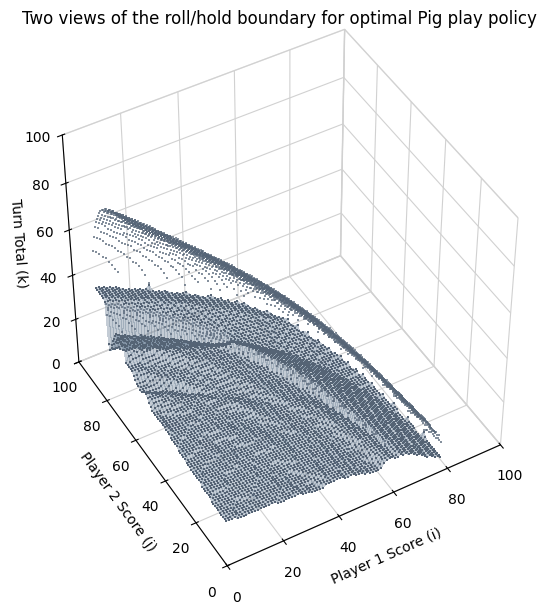

In [23]:
ax = op.plot_figure3_policy_boundary(full_fig3_data, 
                                     title="Two views of the roll/hold boundary for optimal Pig play policy")
ax.view_init(elev=45, azim=240)
plt.show()

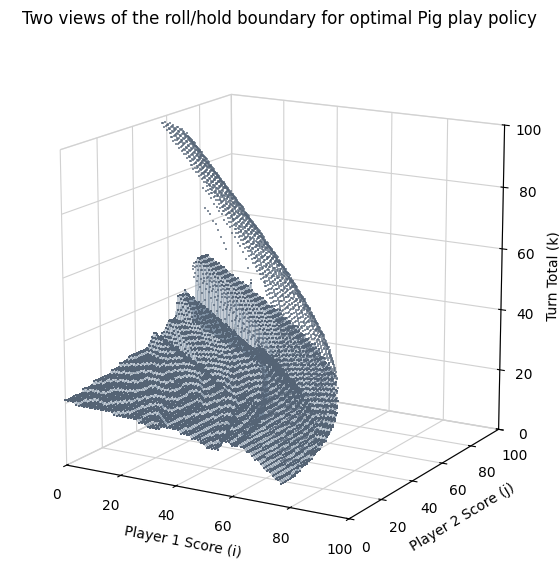

In [24]:
ax = op.plot_figure3_policy_boundary(full_fig3_data, 
                                     title="Two views of the roll/hold boundary for optimal Pig play policy")
ax.view_init(elev=15, azim=-60)
plt.show()

### 5.2.2. Figure 4

By restricting $k$, we do not have turn total values for player $i$ beyond approximately $75$. The turn total increases to $50$ due to the way the plot is generated to be able to account for various boundaries.

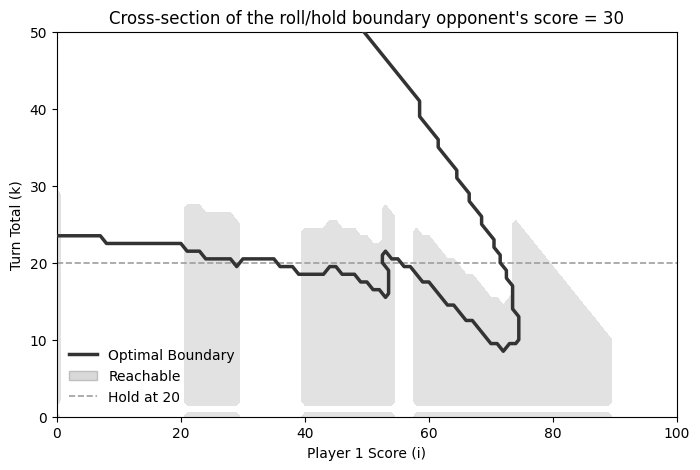

In [25]:
op.plot_figure4_cross_section(
    full_fig4_data,
    hold_at_threshold=20,
    title="Cross-section of the roll/hold boundary opponent's score = 30"
)
plt.ylim(0, 50)
plt.xlim(0, 100)
plt.show()

## 5.3. Use the full optimal policy in the actual Pig simulator

This is not required to extract the article's main conclusions, because the value table `V` and policy table already contain the full solution. However, it is useful as a practical demonstration that the solved policy can actually play the game.

We also compare the optimal policy against the popular hold at $20$ policy (the player continues rolling until their round score is $20$, at which point they hold).

### 5.3.1. Optimal player goes first, hold at $20$ player goes second

In [26]:
if RUN_FULL_PIG:
    full_optimal_policy = op.optimal_policy_function(full_pig_spec, full_V)

    final_state = op.play_pig(
        policy0=full_optimal_policy,
        policy1=op.hold_at_20_policy,
        target_score=100,
        seed=6006011,
        first_player=0,
    )

    print("Full Pig, optimal first player vs hold-at-20 second player:")
    print(final_state)
else:
    print("Full policy game simulation skipped because RUN_FULL_PIG is False.")

Full Pig, optimal first player vs hold-at-20 second player:
PigState(scores=(104, 45), turn_total=0, current_player=0, winner=0)


In [27]:
if RUN_FULL_PIG:
    import random

    N_GAMES = 200_000
    rng = random.Random(20260430)

    optimal_wins = 0
    hold20_wins = 0

    for game_id in range(N_GAMES):
        game_seed = rng.randint(0, 10**12)

        final_state = op.play_pig(
            policy0=full_optimal_policy,
            policy1=op.hold_at_20_policy,
            target_score=100,
            seed=game_seed,
            first_player=0,
        )

        if final_state.winner == 0:
            optimal_wins += 1
        else:
            hold20_wins += 1

    optimal_win_rate = optimal_wins / N_GAMES
    hold20_win_rate = hold20_wins / N_GAMES

    optimal_win_lower = optimal_win_rate - 1.96 * math.sqrt(optimal_win_rate*(1-optimal_win_rate)/N_GAMES)
    optimal_win_upper = optimal_win_rate + 1.96 * math.sqrt(optimal_win_rate*(1-optimal_win_rate)/N_GAMES)

    print("Optimal policy vs hold-at-20 policy")
    print(f"Number of games: {N_GAMES}")
    print(f"Optimal wins: {optimal_wins}")
    print(f"Hold-at-20 wins: {hold20_wins}")
    print(f"Optimal win rate: {optimal_win_rate:.4f}")
    print(f"Optimal win rate confidence intervals: {optimal_win_lower:.4f}, {optimal_win_upper:.4f}")
    print(f"Hold-at-20 win rate: {hold20_win_rate:.4f}")
    print("Article reference: optimal first player vs hold-at-20 second player ≈ 0.5874")

else:
    print("Multi-game simulation skipped because RUN_FULL_PIG is False.")

Optimal policy vs hold-at-20 policy
Number of games: 200000
Optimal wins: 114840
Hold-at-20 wins: 85160
Optimal win rate: 0.5742
Optimal win rate confidence intervals: 0.5720, 0.5764
Hold-at-20 win rate: 0.4258
Article reference: optimal first player vs hold-at-20 second player ≈ 0.5874


### 5.3.2. Hold at $20$ player goes first, optimal policy player goes second

In [28]:
if RUN_FULL_PIG:
    full_optimal_policy = op.optimal_policy_function(full_pig_spec, full_V)

    final_state = op.play_pig(
        policy0= op.hold_at_20_policy,
        policy1= full_optimal_policy,
        target_score=100,
        seed=6006011,
        first_player=0,
    )

    print("Full Pig, hold-at-20 second player vs optimal first player:")
    print(final_state)
else:
    print("Full policy game simulation skipped because RUN_FULL_PIG is False.")

Full Pig, optimal first player vs hold-at-20 second player:
PigState(scores=(68, 100), turn_total=0, current_player=1, winner=1)


In [34]:
if RUN_FULL_PIG:
    import random

    N_GAMES = 200_000
    rng = random.Random(20260430)

    optimal_wins = 0
    hold20_wins = 0

    for game_id in range(N_GAMES):
        game_seed = rng.randint(0, 10**12)

        final_state = op.play_pig(
            policy0= op.hold_at_20_policy,
            policy1= full_optimal_policy,
            target_score=100,
            seed=game_seed,
            first_player=0,
        )

        if final_state.winner == 0:
            hold20_wins  += 1
        else:
            optimal_wins += 1

    optimal_win_rate = optimal_wins / N_GAMES
    hold20_win_rate = hold20_wins / N_GAMES

    optimal_win_lower = optimal_win_rate - 1.96 * math.sqrt(optimal_win_rate*(1-optimal_win_rate)/N_GAMES)
    optimal_win_upper = optimal_win_rate + 1.96 * math.sqrt(optimal_win_rate*(1-optimal_win_rate)/N_GAMES)

    print("Optimal policy vs hold-at-20 policy")
    print(f"Number of games: {N_GAMES}")
    print(f"Optimal wins: {optimal_wins}")
    print(f"Hold-at-20 wins: {hold20_wins}")
    print(f"Optimal win rate: {optimal_win_rate:.4f}")
    print(f"Optimal win rate confidence intervals: {optimal_win_lower:.4f}, {optimal_win_upper:.4f}")
    print(f"Hold-at-20 win rate: {hold20_win_rate:.4f}")
    print("Article reference: optimal first player vs hold-at-20 second player ≈ 0.5224")

else:
    print("Multi-game simulation skipped because RUN_FULL_PIG is False.")

Optimal policy vs hold-at-20 policy
Number of games: 200000
Optimal wins: 101189
Hold-at-20 wins: 98811
Optimal win rate: 0.5059
Optimal win rate confidence intervals: 0.5038, 0.5081
Hold-at-20 win rate: 0.4941
Article reference: optimal first player vs hold-at-20 second player ≈ 0.5224


### 5.3.3. Both players play optimally

In [31]:
if RUN_FULL_PIG:
    full_optimal_policy = op.optimal_policy_function(full_pig_spec, full_V)

    final_state = op.play_pig(
        policy0= full_optimal_policy,
        policy1= full_optimal_policy,
        target_score=100,
        seed=6006011,
        first_player=0,
    )

    print("Full Pig, optimal first player vs optimal first player:")
    print(final_state)
else:
    print("Full policy game simulation skipped because RUN_FULL_PIG is False.")

Full Pig, optimal first player vs hold-at-20 second player:
PigState(scores=(74, 104), turn_total=0, current_player=1, winner=1)


In [32]:
if RUN_FULL_PIG:
    import random

    N_GAMES = 200_000
    rng = random.Random(20260430)

    optimal_wins = 0
    hold20_wins = 0

    for game_id in range(N_GAMES):
        game_seed = rng.randint(0, 10**12)

        final_state = op.play_pig(
            policy0=full_optimal_policy,
            policy1=full_optimal_policy,
            target_score=100,
            seed=game_seed,
            first_player=0,
        )

        if final_state.winner == 0:
            optimal_wins += 1
        else:
            hold20_wins += 1

    optimal_win_rate = optimal_wins / N_GAMES
    hold20_win_rate = hold20_wins / N_GAMES

    optimal_win_lower = optimal_win_rate - 1.96 * math.sqrt(optimal_win_rate*(1-optimal_win_rate)/N_GAMES)
    optimal_win_upper = optimal_win_rate + 1.96 * math.sqrt(optimal_win_rate*(1-optimal_win_rate)/N_GAMES)

    print("Optimal policy vs hold-at-20 policy")
    print(f"Number of games: {N_GAMES}")
    print(f"Optimal wins: {optimal_wins}")
    print(f"Hold-at-20 wins: {hold20_wins}")
    print(f"Optimal win rate: {optimal_win_rate:.4f}")
    print(f"Optimal win rate confidence intervals: {optimal_win_lower:.4f}, {optimal_win_upper:.4f}")
    print(f"Hold-at-20 win rate: {hold20_win_rate:.4f}")
    print("Article reference: optimal first player vs optimal second player ≈ 0.5306")

else:
    print("Multi-game simulation skipped because RUN_FULL_PIG is False.")

Optimal policy vs hold-at-20 policy
Number of games: 200000
Optimal wins: 106381
Hold-at-20 wins: 93619
Optimal win rate: 0.5319
Optimal win rate confidence intervals: 0.5297, 0.5341
Hold-at-20 win rate: 0.4681
Article reference: optimal first player vs hold-at-20 second player ≈ 0.5874


## 6. Final checklist

If the notebook ran successfully, the following should be true:

1. Pig can both run as games.
2. The state count for full Pig is 505,000 (restricted).
3. Full and partitioned value iteration agree on a small Pig instance.
4. The solved policy can be converted into a real game-playing policy.
5. The helper functions can extract boundary, reachability, and probability-contour data.
6. The optional full Pig solve should give $P_{0,0,0}\approx 0.5306$, matching the paper.